# Proj1 Bonus: 自定义图片对 + Cutoff 调参

本 notebook 用于 extra credit：
1. 先自定义图片对
2. 再批量调参（`cutoff`）
3. 生成可用于 writeup 的结果图与分析模板

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Saved to: ../results/bonus/my_hybrid_example


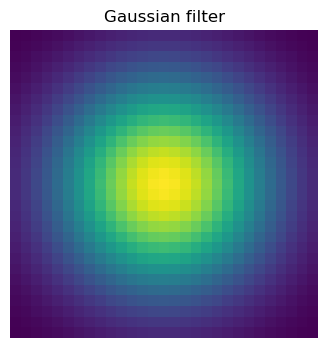

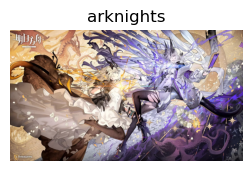

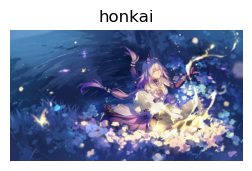

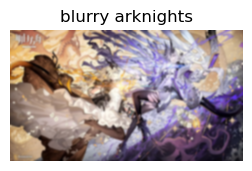

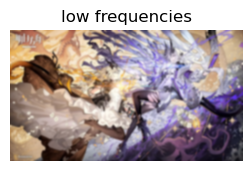

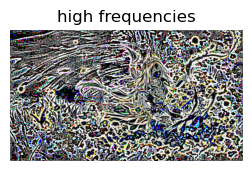

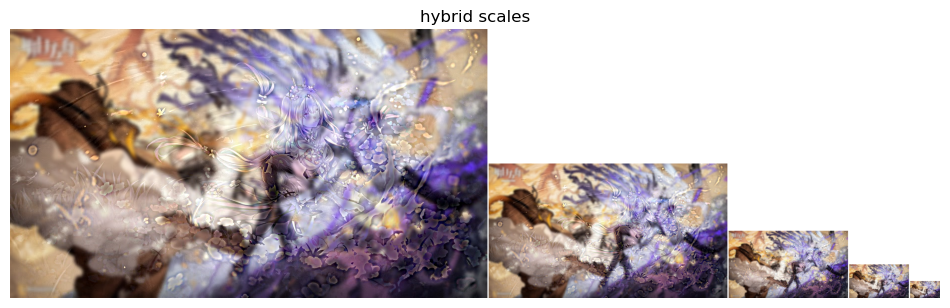

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from utils import vis_hybrid_image, load_image, save_image
from student_code import my_imfilter, create_hybrid_image
%load_ext autoreload
%autoreload 2

# ===== arknights + honkai (same pipeline as proj1 cat_dog example) =====
image1 = load_image('../data/arknights.png')
image2 = load_image('../data/Honkai_Starrail.jpg')

def resize_to_match(image_ref, image_to_resize):
    h, w = image_ref.shape[:2]
    return cv2.resize(image_to_resize, (w, h), interpolation=cv2.INTER_LINEAR)

if image1.shape != image2.shape:
    image2 = resize_to_match(image1, image2)

cutoff_frequency = 7
filter_kernel = cv2.getGaussianKernel(ksize=cutoff_frequency * 4 + 1, sigma=cutoff_frequency)
filter_kernel = np.dot(filter_kernel, filter_kernel.T)

plt.figure(figsize=(4, 4)); plt.imshow(filter_kernel); plt.title('Gaussian filter'); plt.axis('off')
plt.figure(figsize=(3, 3)); plt.imshow((image1 * 255).astype(np.uint8)); plt.title('arknights'); plt.axis('off')
plt.figure(figsize=(3, 3)); plt.imshow((image2 * 255).astype(np.uint8)); plt.title('honkai'); plt.axis('off')

blurry_image1 = my_imfilter(image1, filter_kernel)
low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, filter_kernel)
hybrid_scales = vis_hybrid_image(hybrid_image)

plt.figure(figsize=(3, 3)); plt.imshow((blurry_image1 * 255).astype(np.uint8)); plt.title('blurry arknights'); plt.axis('off')
plt.figure(figsize=(3, 3)); plt.imshow((low_frequencies * 255).astype(np.uint8)); plt.title('low frequencies'); plt.axis('off')
plt.figure(figsize=(3, 3)); plt.imshow((high_frequencies * 255).astype(np.uint8)); plt.title('high frequencies'); plt.axis('off')
plt.figure(figsize=(12, 4)); plt.imshow(hybrid_scales); plt.title('hybrid scales'); plt.axis('off')

my_hybrid = '../results/bonus/my_hybrid_example'
os.makedirs(my_hybrid, exist_ok=True)
save_image(os.path.join(my_hybrid, 'low_frequencies.jpg'), low_frequencies)
save_image(os.path.join(my_hybrid, 'high_frequencies.jpg'), high_frequencies)
save_image(os.path.join(my_hybrid, 'hybrid_image.jpg'), hybrid_image)
save_image(os.path.join(my_hybrid, 'hybrid_image_scales.jpg'), hybrid_scales)

print('Saved to:', my_hybrid)

In [ ]:
# =====  custom pairs for cutoff tuning =====
CUSTOM_PAIRS = [
    ('cat_dog', '../data/cat.bmp', '../data/dog.bmp'),
    ('submarine_fish', '../data/submarine.bmp', '../data/fish.bmp'),
    ('bird_plane', '../data/bird.bmp', '../data/plane.bmp'),
]

# Tune cutoff on these pairs
CUTOFF_LIST = [1, 2, 3, 4, 5, 6, 7, 8]
RESIZE_IF_NEEDED = True

BONUS_ROOT = '../results/bonus/cutoff_tuning'
os.makedirs(BONUS_ROOT, exist_ok=True)

print('当前自定义图片对:')
for p in CUSTOM_PAIRS:
    print('-', p)
print('结果输出目录:', BONUS_ROOT)

当前自定义图片对:
- ('cat_dog', '../data/cat.bmp', '../data/dog.bmp')
- ('submarine_fish', '../data/submarine.bmp', '../data/fish.bmp')
- ('bird_plane', '../data/bird.bmp', '../data/plane.bmp')
结果输出目录: ../results/bonus/cutoff_tuning


Step 2 generated results:
('cat_dog', 1, '../results/bonus/cutoff_tuning\\cat_dog\\cutoff_1_hybrid_scales.jpg')
('cat_dog', 2, '../results/bonus/cutoff_tuning\\cat_dog\\cutoff_2_hybrid_scales.jpg')
('cat_dog', 3, '../results/bonus/cutoff_tuning\\cat_dog\\cutoff_3_hybrid_scales.jpg')
('cat_dog', 4, '../results/bonus/cutoff_tuning\\cat_dog\\cutoff_4_hybrid_scales.jpg')
('cat_dog', 5, '../results/bonus/cutoff_tuning\\cat_dog\\cutoff_5_hybrid_scales.jpg')
('cat_dog', 6, '../results/bonus/cutoff_tuning\\cat_dog\\cutoff_6_hybrid_scales.jpg')
('cat_dog', 7, '../results/bonus/cutoff_tuning\\cat_dog\\cutoff_7_hybrid_scales.jpg')
('cat_dog', 8, '../results/bonus/cutoff_tuning\\cat_dog\\cutoff_8_hybrid_scales.jpg')
('submarine_fish', 1, '../results/bonus/cutoff_tuning\\submarine_fish\\cutoff_1_hybrid_scales.jpg')
('submarine_fish', 2, '../results/bonus/cutoff_tuning\\submarine_fish\\cutoff_2_hybrid_scales.jpg')
('submarine_fish', 3, '../results/bonus/cutoff_tuning\\submarine_fish\\cutoff_3_hybrid

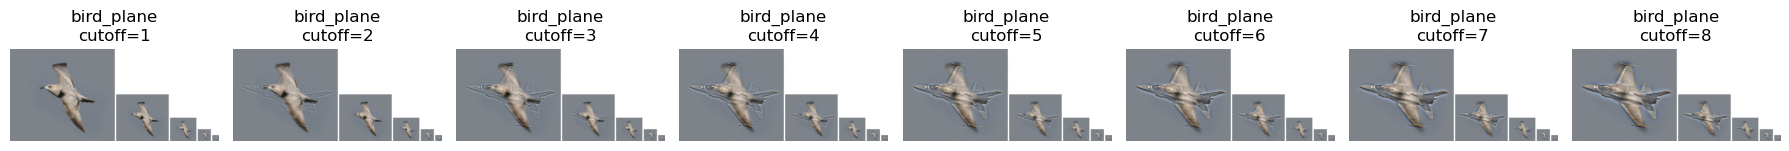

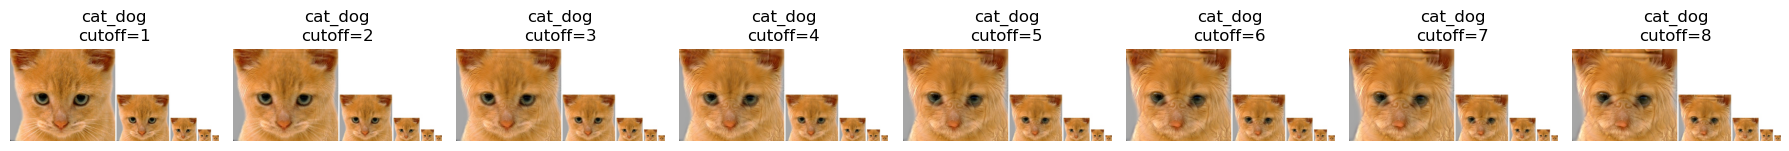

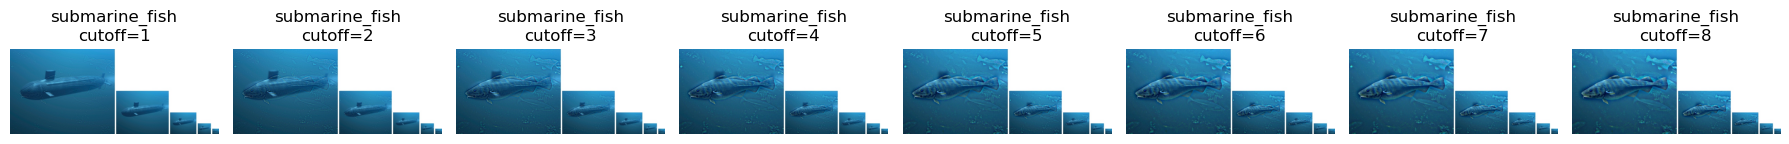

In [ ]:
# ===== cutoff tuning and visualization =====
def gaussian_2d(cutoff_frequency):
    g = cv2.getGaussianKernel(ksize=cutoff_frequency * 4 + 1, sigma=cutoff_frequency)
    return np.dot(g, g.T)

summary = []
skipped = []

for pair_name, img1_path, img2_path in CUSTOM_PAIRS:
    if (not os.path.exists(img1_path)) or (not os.path.exists(img2_path)):
        skipped.append((pair_name, 'missing file'))
        continue

    image1 = load_image(img1_path)
    image2 = load_image(img2_path)

    if image1.shape != image2.shape:
        if RESIZE_IF_NEEDED:
            image2 = resize_to_match(image1, image2)
        else:
            skipped.append((pair_name, f'shape mismatch: {image1.shape} vs {image2.shape}'))
            continue

    pair_dir = os.path.join(BONUS_ROOT, pair_name)
    os.makedirs(pair_dir, exist_ok=True)

    for cutoff_frequency in CUTOFF_LIST:
        filter_kernel = gaussian_2d(cutoff_frequency)
        low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, filter_kernel)
        hybrid_scales = vis_hybrid_image(hybrid_image)

        prefix = os.path.join(pair_dir, f'cutoff_{cutoff_frequency}')
        save_image(prefix + '_low.jpg', low_frequencies)
        save_image(prefix + '_high.jpg', high_frequencies)
        save_image(prefix + '_hybrid.jpg', hybrid_image)
        save_image(prefix + '_hybrid_scales.jpg', hybrid_scales)

        summary.append((pair_name, cutoff_frequency, prefix + '_hybrid_scales.jpg'))

print('Step 2 generated results:')
for item in summary:
    print(item)

if skipped:
    print('\nSkipped pairs:')
    for item in skipped:
        print(item)

valid_pairs = sorted(set([p for p, _, _ in summary]))
for pair_name in valid_pairs:
    plt.figure(figsize=(18, 4))
    plot_idx = 1
    for cutoff_frequency in CUTOFF_LIST:
        vis_path = os.path.join(BONUS_ROOT, pair_name, f'cutoff_{cutoff_frequency}_hybrid_scales.jpg')
        if not os.path.exists(vis_path):
            continue
        vis_img = load_image(vis_path)
        plt.subplot(1, len(CUTOFF_LIST), plot_idx)
        plt.imshow((vis_img * 255).astype(np.uint8))
        plt.title(f'{pair_name}\ncutoff={cutoff_frequency}')
        plt.axis('off')
        plot_idx += 1
    plt.tight_layout()
    plt.show()

## Bonus Writeup

### Step 1: arknights + honkai（固定 cutoff = 7）
- 结果图：![arknights_honkai](../results/bonus/my_hybrid_example/hybrid_image_scales.jpg)
- 观察：该组合纹理密度和色彩复杂度都很高，在近看与远看下都保留了大量细节。
- 分析：可以形成有效 hybrid，但主导信息切换不如人脸或猫狗样例直观，主要因为两张图本身都包含丰富高频纹理。

### Step 2: 三组图片 cutoff 调参（1~8）

#### 1) cat_dog
- 典型对比：
  - cutoff=1：![cat_dog_c1](../results/bonus/cutoff_tuning/cat_dog/cutoff_1_hybrid_scales.jpg)
  - cutoff=4：![cat_dog_c4](../results/bonus/cutoff_tuning/cat_dog/cutoff_4_hybrid_scales.jpg)
  - cutoff=8：![cat_dog_c8](../results/bonus/cutoff_tuning/cat_dog/cutoff_8_hybrid_scales.jpg)
- 现象：
  - cutoff=1 时猫脸占主导，整体较干净，但“近看狗”的高频感偏弱。
  - cutoff=4 时狗的细节开始明显，远近切换更自然。
  - cutoff=8 时狗的轮廓叠加更强，出现更明显重影感。
- 结论：该组较合适的区间为 4~6。

#### 2) submarine_fish
- 典型对比：
  - cutoff=1：![submarine_fish_c1](../results/bonus/cutoff_tuning/submarine_fish/cutoff_1_hybrid_scales.jpg)
  - cutoff=4：![submarine_fish_c4](../results/bonus/cutoff_tuning/submarine_fish/cutoff_4_hybrid_scales.jpg)
  - cutoff=8：![submarine_fish_c8](../results/bonus/cutoff_tuning/submarine_fish/cutoff_8_hybrid_scales.jpg)
- 现象：
  - cutoff=1 时潜艇轮廓占主导，鱼的纹理细节偏弱。
  - cutoff=4 时鱼体细节与背景结构平衡较好，视觉最自然。
  - cutoff=8 时鱼的细节更强，但画面混合感增加，切换边界略显复杂。
- 结论：该组推荐 cutoff 约为 4（或 4~6 区间）。

#### 3) bird_plane
- 典型对比：
  - cutoff=1：![bird_plane_c1](../results/bonus/cutoff_tuning/bird_plane/cutoff_1_hybrid_scales.jpg)
  - cutoff=4：![bird_plane_c4](../results/bonus/cutoff_tuning/bird_plane/cutoff_4_hybrid_scales.jpg)
  - cutoff=8：![bird_plane_c8](../results/bonus/cutoff_tuning/bird_plane/cutoff_8_hybrid_scales.jpg)
- 现象：
  - cutoff=1 时鸟的高频边缘较明显，飞机主体不够稳定。
  - cutoff=4 时飞机结构更清楚，混合结果更平衡。
  - cutoff=8 与 cutoff=4 效果接近，但整体更偏平滑，细节冲突略减。
- 结论：该组在 4~8 均可用，若追求稳定可取 6~8，若追求切换感可取 4~6。

### 总体结论
- 本次实验中，cutoff 主要控制“高频细节强度”和“重影风险”之间的平衡。
- cutoff 过小时，结果更干净但高频切换偏弱；cutoff 过大时，高频叠加更强但更容易出现混合冲突。
- 对本数据集来说，中等区间（约 4~6）整体最稳健，通常能同时保留可识别细节与较自然的远近切换。